In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

df = pd.read_csv(url)

print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
print(df.info())
print(df.isnull().sum())

In [ ]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1             80                

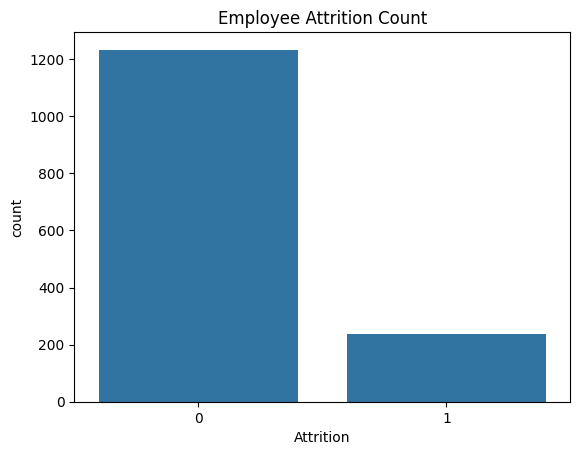

In [5]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Count")
plt.show()

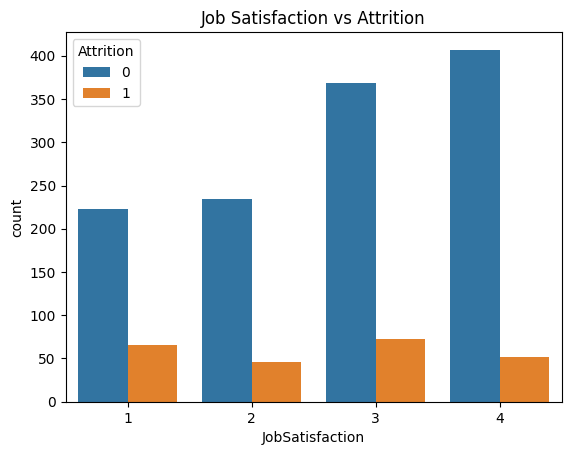

In [6]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

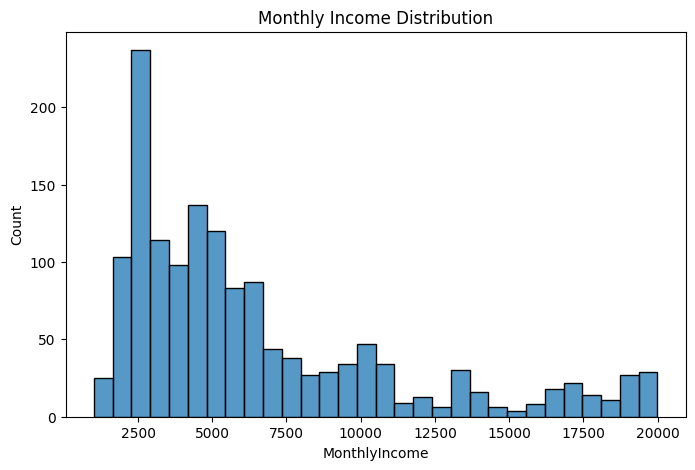

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyIncome'], bins=30)
plt.title("Monthly Income Distribution")
plt.show()

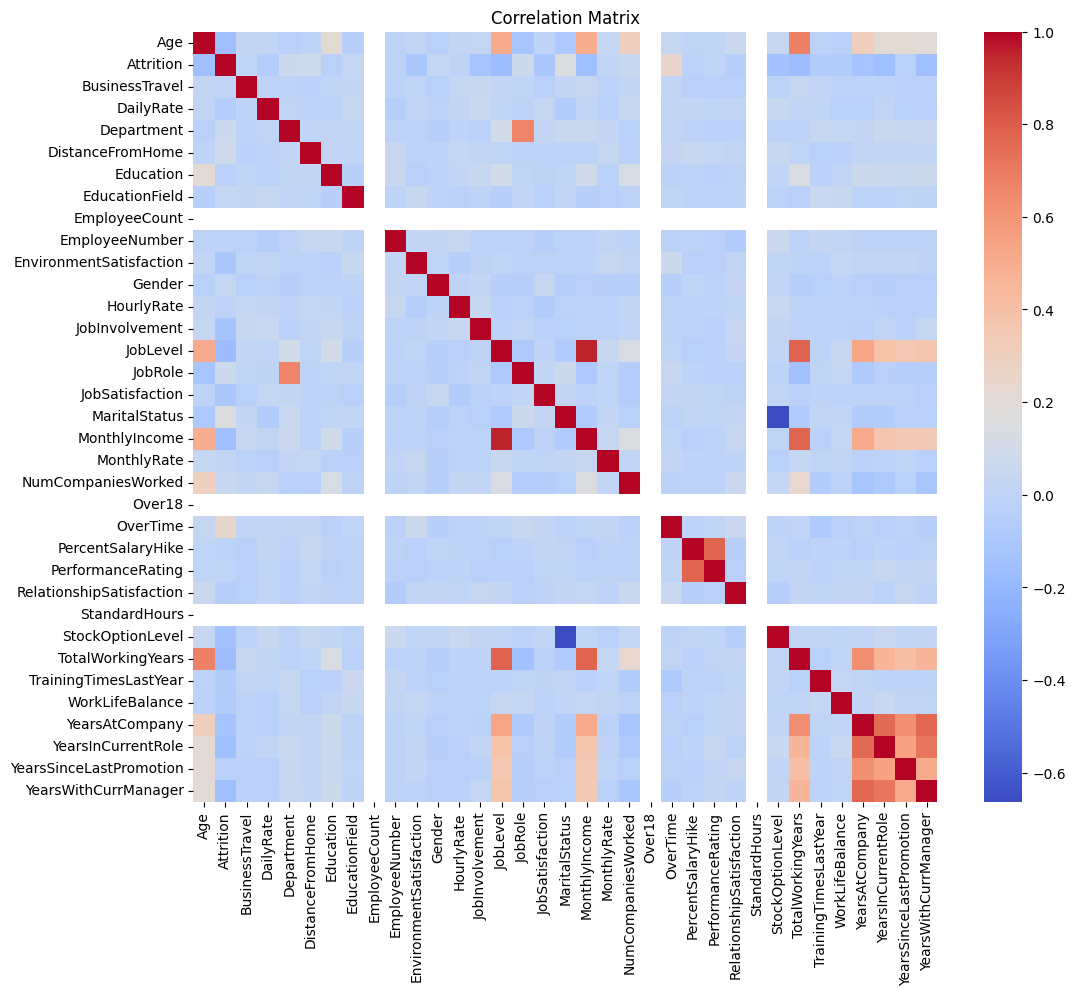

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
y = df['Attrition']
X = df.drop('Attrition', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, prediction))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, prediction))

Accuracy: 0.8673469387755102

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294


Confusion Matrix
[[251   4]
 [ 35   4]]


In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

              Feature  Importance
17      MonthlyIncome    0.074968
21           OverTime    0.064823
0                 Age    0.056865
2           DailyRate    0.050505
27  TotalWorkingYears    0.048104
18        MonthlyRate    0.047090
8      EmployeeNumber    0.045296
11         HourlyRate    0.043352
4    DistanceFromHome    0.042012
30     YearsAtCompany    0.041914


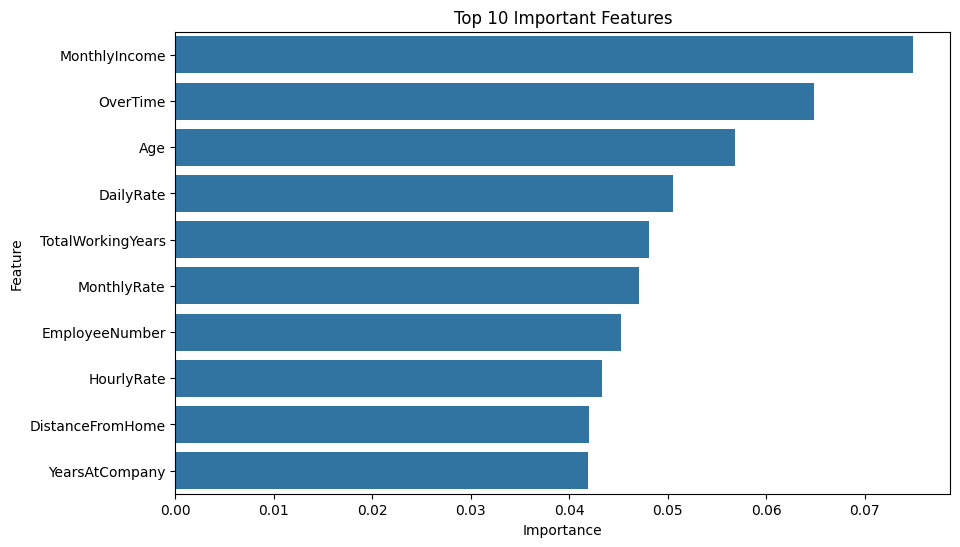

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [14]:
new_employee = X.iloc[0].values.reshape(1, -1)

result = model.predict(new_employee)

if result[0] == 1:
    print("Prediction: Employee is likely to leave.")
else:
    print("Prediction: Employee is likely to stay.")

Prediction: Employee is likely to leave.


c:\Users\AMD\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
